## Phase 1+: Run Linear Probes on Single Dataset's Residual Branches: LLaMA-2-7B on Trivia-QA (1k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.


We study effects of residual branch and mlp outputs in this notebook.

In [17]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb

os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/xxx/files')  # 1000 test samples
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_215314-4h8sr68g/files')  # 20 test samples
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_202225-5ggqq6ks/files')  # wrong
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240504_011432-t3d0d4kb/files')  # wrong

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utility Functions

In [18]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [19]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([20]) tensor([2.0253, 1.6094, 2.0253, 1.3592, 1.1683, 2.3026, 0.6390, 2.3026, 1.8867,
        2.0253, 1.3592, 2.3026, 0.3251, 2.0253, 2.1640, 2.3026, 2.0253, 2.1640,
        2.3026, 2.3026])


In [20]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

## Use Linear Probe for Predicting Semantic Entropy 

In [74]:
# # Hidden states:
# slt_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
#                                    for record in generations.values()]).squeeze(-2).to(torch.float32)

# # Residual connection:
# slt_dataset = torch.cat([torch.stack([layer[:,-1,:] for layer in record['most_likely_answer']['res_embeds']], dim=1)
#                                     for record in generations.values()], dim=0).to(torch.float32)

# MLP outputs:
slt_dataset = torch.cat([torch.stack([layer[:,-1,:] for layer in record['most_likely_answer']['mlp_embeds']], dim=1)
                                    for record in generations.values()], dim=0).to(torch.float32)

print(slt_dataset.shape)

torch.Size([20, 32, 4096])


In [77]:
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
ca_entropy = (ca_entropy - mean) / std
print(ca_entropy.shape)

torch.Size([20])


In [75]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [57]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [59]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name} per Layer')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices)  # Assuming all models have the same number of layers
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

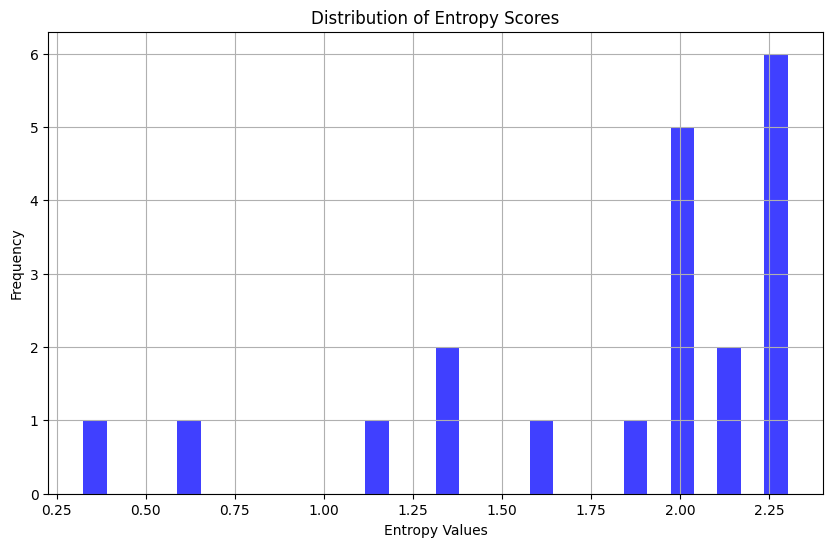

In [76]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.0931464735228855

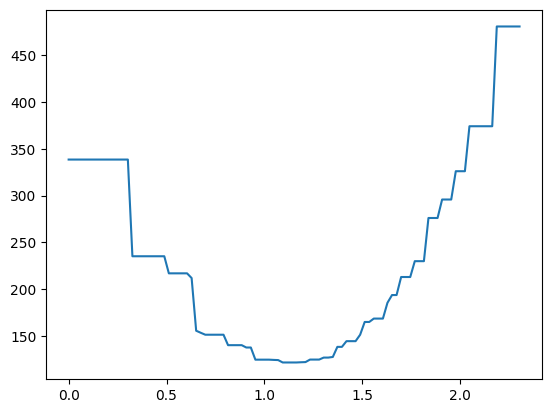

In [11]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [12]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.6740


### Explore Second Last generated Token (SLT)


In [18]:
slt_layered_datasets = slt_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 1000, 4096]) torch.float32


In [19]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [20]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.7222, AUROC: 0.5000
Training Loss: 0.6346, Validation Loss: 0.5973
Test Loss: 0.6695, Test Accuracy: 0.6200, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.7222, AUROC: 0.7345
Training Loss: 0.6242, Validation Loss: 0.5851
Test Loss: 0.6643, Test Accuracy: 0.6200, AUROC: 0.5857
Training on Dataset 3/33
Validation Accuracy: 0.7222, AUROC: 0.7463
Training Loss: 0.6107, Validation Loss: 0.5698
Test Loss: 0.6522, Test Accuracy: 0.6200, AUROC: 0.6426
Training on Dataset 4/33
Validation Accuracy: 0.7444, AUROC: 0.7725
Training Loss: 0.5927, Validation Loss: 0.5454
Test Loss: 0.6335, Test Accuracy: 0.6200, AUROC: 0.6783
Training on Dataset 5/33
Validation Accuracy: 0.7944, AUROC: 0.7906
Training Loss: 0.5786, Validation Loss: 0.5291
Test Loss: 0.6182, Test Accuracy: 0.6700, AUROC: 0.7042
Training on Dataset 6/33
Validation Accuracy: 0.8056, AUROC: 0.8178
Training Loss: 0.5449, Validation Loss: 0.5103
Test Loss: 0.5932, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7889, AUROC: 0.8240
Training Loss: 0.2677, Validation Loss: 0.4363
Test Loss: 0.4315, Test Accuracy: 0.8200, AUROC: 0.8888
Training on Dataset 13/33
Validation Accuracy: 0.8222, AUROC: 0.8766
Training Loss: 0.2071, Validation Loss: 0.3946
Test Loss: 0.3907, Test Accuracy: 0.8100, AUROC: 0.9041
Training on Dataset 14/33
Validation Accuracy: 0.8333, AUROC: 0.8969
Training Loss: 0.1387, Validation Loss: 0.3925
Test Loss: 0.3367, Test Accuracy: 0.8800, AUROC: 0.9287
Training on Dataset 15/33
Validation Accuracy: 0.8333, AUROC: 0.8906
Training Loss: 0.1089, Validation Loss: 0.4230
Test Loss: 0.3249, Test Accuracy: 0.8600, AUROC: 0.9325
Training on Dataset 16/33
Validation Accuracy: 0.8389, AUROC: 0.9182
Training Loss: 0.0837, Validation Loss: 0.3514
Test Loss: 0.3758, Test Accuracy: 0.8700, AUROC: 0.9215
Training on Dataset 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8500, AUROC: 0.9085
Training Loss: 0.0730, Validation Loss: 0.3895
Test Loss: 0.3581, Test Accuracy: 0.8700, AUROC: 0.9223
Training on Dataset 18/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.9028
Training Loss: 0.0136, Validation Loss: 0.6448
Test Loss: 0.9483, Test Accuracy: 0.8000, AUROC: 0.8527
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8985
Training Loss: 0.0123, Validation Loss: 0.7008
Test Loss: 1.0735, Test Accuracy: 0.7900, AUROC: 0.8442
Training on Dataset 33/33
Validation Accuracy: 0.8389, AUROC: 0.9012
Training Loss: 0.0200, Validation Loss: 0.5956
Test Loss: 0.8640, Test Accuracy: 0.8100, AUROC: 0.8548


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.9325 at layer 15


## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [23]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([1000]) tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 1.])


In [24]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [25]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.5100


In [26]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.5611, AUROC: 0.5538
Training Loss: 0.6633, Validation Loss: 0.6709
Test Loss: 0.7037, Test Accuracy: 0.5200, AUROC: 0.5308
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.6111, AUROC: 0.6483
Training Loss: 0.6279, Validation Loss: 0.6402
Test Loss: 0.6814, Test Accuracy: 0.5200, AUROC: 0.5926
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.6167, AUROC: 0.6842
Training Loss: 0.5996, Validation Loss: 0.6239
Test Loss: 0.6680, Test Accuracy: 0.5300, AUROC: 0.6351
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.6389, AUROC: 0.7062
Training Loss: 0.5491, Validation Loss: 0.6065
Test Loss: 0.6725, Test Accuracy: 0.5400, AUROC: 0.6287
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.6778, AUROC: 0.7473
Training Loss: 0.4802, Validation Loss: 0.5784
Test Loss: 0.6754, Test Accuracy: 0.5600, AUROC: 0.6391
Training on TBG-Acc Dataset 6/33
Validation Accuracy: 0.6889, AUROC: 0.7756
Training Loss: 0.4346, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.8066
Training Loss: 0.2938, Validation Loss: 0.5429
Test Loss: 0.6505, Test Accuracy: 0.6500, AUROC: 0.7247
Training on TBG-Acc Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.8064
Training Loss: 0.2409, Validation Loss: 0.5529
Test Loss: 0.6444, Test Accuracy: 0.6800, AUROC: 0.7519
Training on TBG-Acc Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8222, AUROC: 0.8720
Training Loss: 0.0047, Validation Loss: 0.8219
Test Loss: 0.9475, Test Accuracy: 0.7700, AUROC: 0.8511
Training on TBG-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8167, AUROC: 0.8911
Training Loss: 0.0040, Validation Loss: 0.7616
Test Loss: 0.9907, Test Accuracy: 0.7700, AUROC: 0.8503
Training on TBG-Acc Dataset 33/33
Validation Accuracy: 0.8333, AUROC: 0.9019
Training Loss: 0.0084, Validation Loss: 0.6946
Test Loss: 1.1204, Test Accuracy: 0.7600, AUROC: 0.8315


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


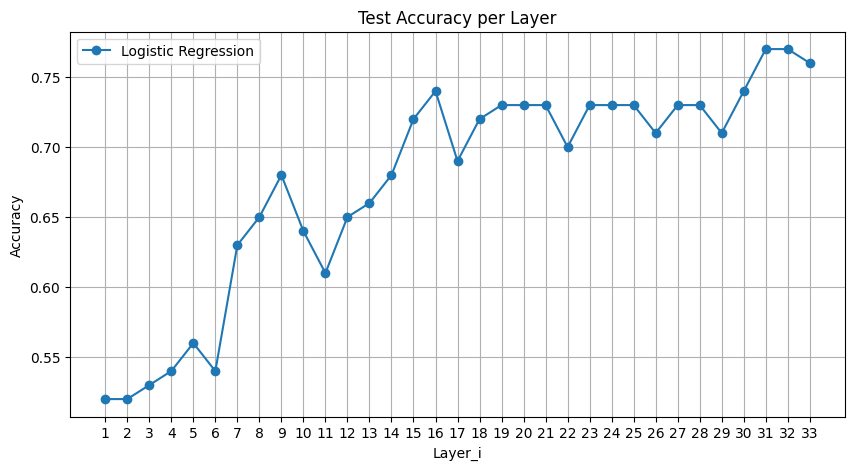

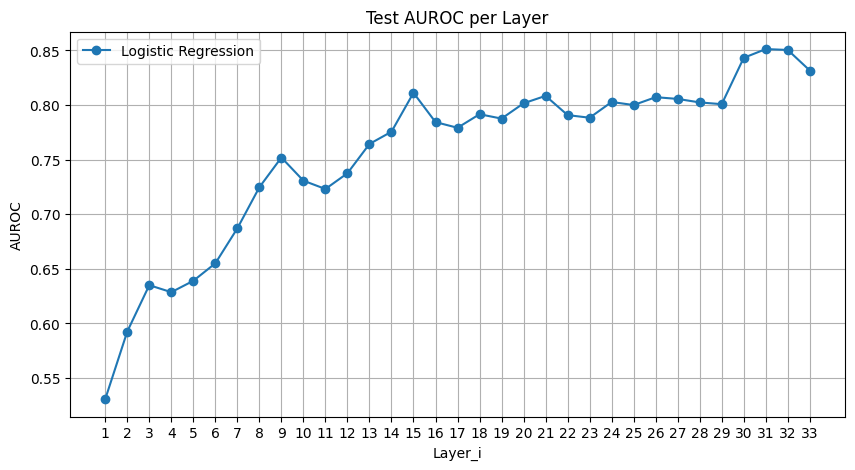

In [27]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [28]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.8511 at layer 31


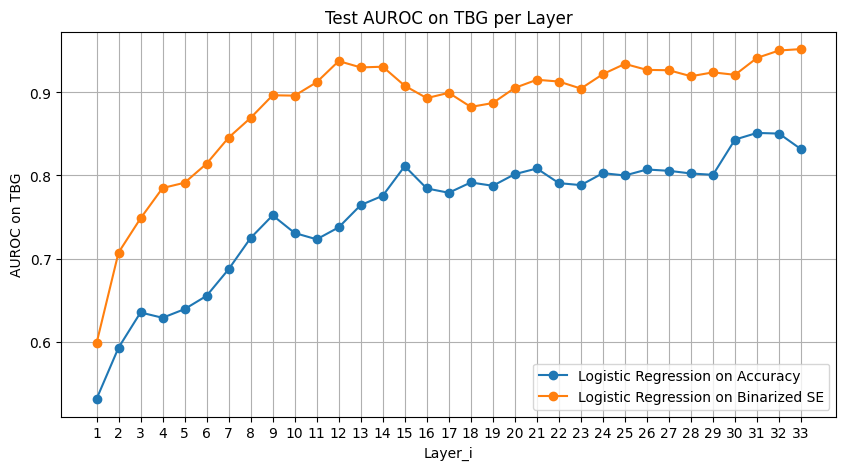

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8511 at 31 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9520 at 33 layer


In [29]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [30]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [31]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.5944, AUROC: 0.5000
Training Loss: 0.6842, Validation Loss: 0.6768
Test Loss: 0.7048, Test Accuracy: 0.4900, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.6000, AUROC: 0.6538
Training Loss: 0.6713, Validation Loss: 0.6652
Test Loss: 0.6955, Test Accuracy: 0.4900, AUROC: 0.6335
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.6222, AUROC: 0.6469
Training Loss: 0.6592, Validation Loss: 0.6562
Test Loss: 0.6788, Test Accuracy: 0.5400, AUROC: 0.7031
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.6389, AUROC: 0.6676
Training Loss: 0.6386, Validation Loss: 0.6399
Test Loss: 0.6608, Test Accuracy: 0.6300, AUROC: 0.6923
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6993
Training Loss: 0.6209, Validation Loss: 0.6225
Test Loss: 0.6373, Test Accuracy: 0.6700, AUROC: 0.7239
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.7222, AUROC: 0.7231
Training Loss: 0.5852, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.7792
Training Loss: 0.3772, Validation Loss: 0.5542
Test Loss: 0.5423, Test Accuracy: 0.7200, AUROC: 0.8127
Training on SLT-Acc Dataset 12/33
Validation Accuracy: 0.7222, AUROC: 0.7865
Training Loss: 0.3179, Validation Loss: 0.5523
Test Loss: 0.5332, Test Accuracy: 0.7400, AUROC: 0.8215
Training on SLT-Acc Dataset 13/33
Validation Accuracy: 0.7444, AUROC: 0.8004
Training Loss: 0.2586, Validation Loss: 0.5701
Test Loss: 0.5516, Test Accuracy: 0.7200, AUROC: 0.8151
Training on SLT-Acc Dataset 14/33
Validation Accuracy: 0.7333, AUROC: 0.8151
Training Loss: 0.1978, Validation Loss: 0.5710
Test Loss: 0.6296, Test Accuracy: 0.7600, AUROC: 0.7871
Training on SLT-Acc Dataset 15/33
Validation Accuracy: 0.7444, AUROC: 0.8068
Training Loss: 0.1587, Validation Loss: 0.6015
Test Loss: 0.5991, Test Accuracy: 0.7400, AUROC: 0.8171
Training on SLT-Acc Dataset 16/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8169
Training Loss: 0.1238, Validation Loss: 0.6045
Test Loss: 0.6894, Test Accuracy: 0.7600, AUROC: 0.8151
Training on SLT-Acc Dataset 17/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7678
Training Loss: 0.0172, Validation Loss: 1.4452
Test Loss: 1.1832, Test Accuracy: 0.7300, AUROC: 0.8163
Training on SLT-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7785
Training Loss: 0.0259, Validation Loss: 1.5797
Test Loss: 1.6357, Test Accuracy: 0.7200, AUROC: 0.7935
Training on SLT-Acc Dataset 33/33
Validation Accuracy: 0.7389, AUROC: 0.7710
Training Loss: 0.0665, Validation Loss: 1.5451
Test Loss: 1.6574, Test Accuracy: 0.6800, AUROC: 0.7647


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


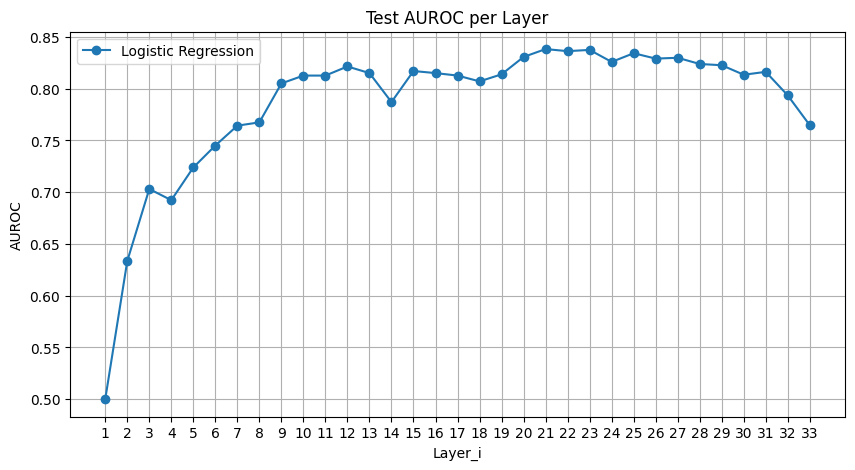

In [32]:
# plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [33]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.8383 at layer 21


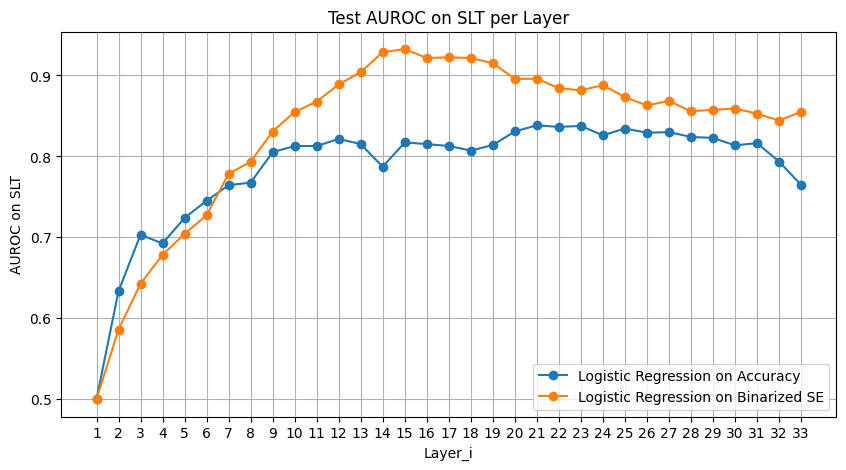

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8383 at 21 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9325 at 15 layer


In [34]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [35]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [36]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.7222, AUROC: 0.6028
Training Loss: 0.6281, Validation Loss: 0.5842
Test Loss: 0.7539, Test Accuracy: 0.4900, AUROC: 0.5392
Training on TBG Dataset 2/33
Validation Accuracy: 0.7222, AUROC: 0.7502
Training Loss: 0.6093, Validation Loss: 0.5533
Test Loss: 0.7336, Test Accuracy: 0.5000, AUROC: 0.6198
Training on TBG Dataset 3/33
Validation Accuracy: 0.7389, AUROC: 0.7518
Training Loss: 0.5803, Validation Loss: 0.5290
Test Loss: 0.7154, Test Accuracy: 0.5200, AUROC: 0.6283
Training on TBG Dataset 4/33
Validation Accuracy: 0.7333, AUROC: 0.7828
Training Loss: 0.5419, Validation Loss: 0.5077
Test Loss: 0.7171, Test Accuracy: 0.5400, AUROC: 0.6242
Training on TBG Dataset 5/33
Validation Accuracy: 0.7944, AUROC: 0.8552
Training Loss: 0.4809, Validation Loss: 0.4681
Test Loss: 0.7182, Test Accuracy: 0.5000, AUROC: 0.6379
Training on TBG Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.8731
Training Loss: 0.4333, Validation Loss: 0.4506
Test Loss: 0.7041, Test Accuracy: 0.5400, AUROC: 0.6563
Training on TBG Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8854
Training Loss: 0.3570, Validation Loss: 0.4164
Test Loss: 0.7172, Test Accuracy: 0.5900, AUROC: 0.6803
Training on TBG Dataset 8/33
Validation Accuracy: 0.8222, AUROC: 0.8726
Training Loss: 0.2764, Validation Loss: 0.4018
Test Loss: 0.7136, Test Accuracy: 0.6300, AUROC: 0.7059
Training on TBG Dataset 9/33
Validation Accuracy: 0.8667, AUROC: 0.8660
Training Loss: 0.2245, Validation Loss: 0.3983
Test Loss: 0.6864, Test Accuracy: 0.6500, AUROC: 0.7451
Training on TBG Dataset 10/33
Validation Accuracy: 0.8278, AUROC: 0.8295
Training Loss: 0.1794, Validation Loss: 0.4567
Test Loss: 0.7592, Test Accuracy: 0.6400, AUROC: 0.7275
Training on TBG Dataset 11/33
Validation Accuracy: 0.8222, AUROC: 0.8411
Training Loss: 0.1333, Validation Loss: 0.4535
Test Loss: 0.8685, Test Accuracy: 0.6200, AUROC: 0.7091
Training on TBG Dataset 12/33
Validation Accuracy: 0.8056, AUROC: 0.8443
Training Loss: 0.0970, Validation Loss: 0.4794
Test Loss: 0.9066, Test Accuracy

...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8556, AUROC: 0.9392
Training Loss: 0.0054, Validation Loss: 0.3683
Test Loss: 1.2768, Test Accuracy: 0.7000, AUROC: 0.8419
Training on TBG Dataset 30/33
Validation Accuracy: 0.8778, AUROC: 0.9478
Training Loss: 0.0038, Validation Loss: 0.3856
Test Loss: 1.3635, Test Accuracy: 0.7300, AUROC: 0.8467
Training on TBG Dataset 31/33
Validation Accuracy: 0.8889, AUROC: 0.9571
Training Loss: 0.0027, Validation Loss: 0.3646
Test Loss: 1.3959, Test Accuracy: 0.7400, AUROC: 0.8723
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8944, AUROC: 0.9580
Training Loss: 0.0021, Validation Loss: 0.3912
Test Loss: 1.4850, Test Accuracy: 0.7400, AUROC: 0.8776
Training on TBG Dataset 33/33
Validation Accuracy: 0.9000, AUROC: 0.9602
Training Loss: 0.0044, Validation Loss: 0.4082
Test Loss: 1.4386, Test Accuracy: 0.7400, AUROC: 0.8836


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


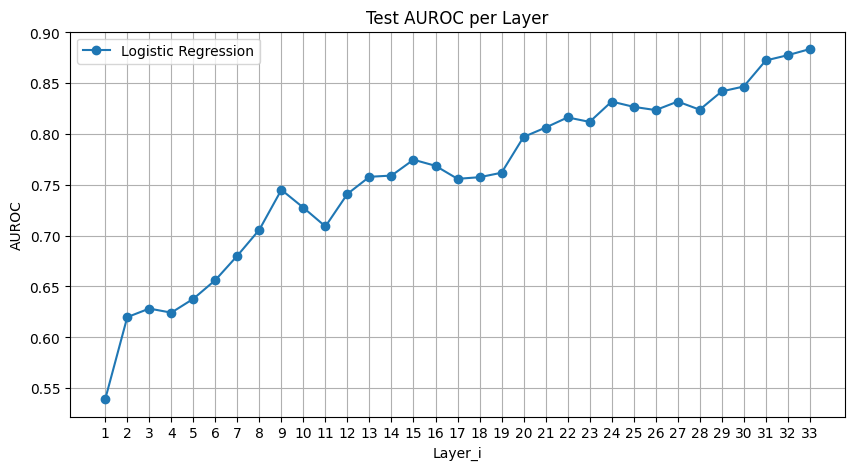

In [37]:
# plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

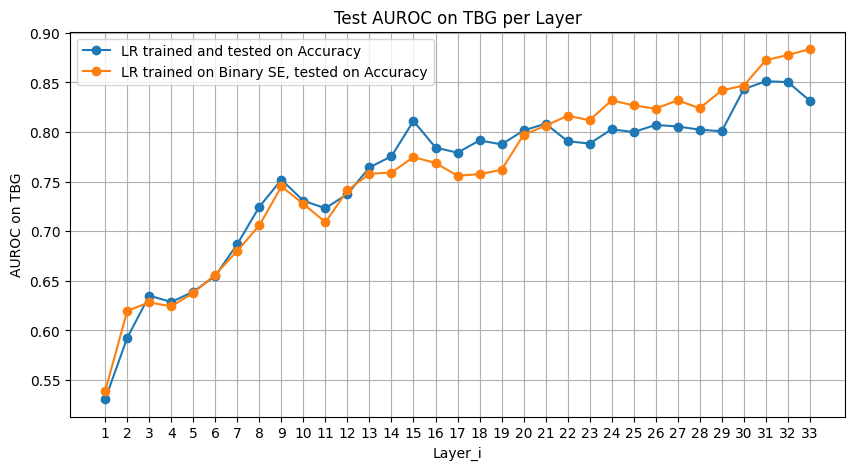

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8511 at 31 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8836 at 33 layer


In [38]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [39]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [40]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.7222, AUROC: 0.5000
Training Loss: 0.6346, Validation Loss: 0.5973
Test Loss: 0.7612, Test Accuracy: 0.4900, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.7222, AUROC: 0.7345
Training Loss: 0.6242, Validation Loss: 0.5851
Test Loss: 0.7529, Test Accuracy: 0.4900, AUROC: 0.6162
Training on SLT Dataset 3/33
Validation Accuracy: 0.7222, AUROC: 0.7463
Training Loss: 0.6107, Validation Loss: 0.5698
Test Loss: 0.7362, Test Accuracy: 0.4900, AUROC: 0.6755
Training on SLT Dataset 4/33
Validation Accuracy: 0.7444, AUROC: 0.7725
Training Loss: 0.5927, Validation Loss: 0.5454
Test Loss: 0.7193, Test Accuracy: 0.4900, AUROC: 0.6783
Training on SLT Dataset 5/33
Validation Accuracy: 0.7944, AUROC: 0.7906
Training Loss: 0.5786, Validation Loss: 0.5291
Test Loss: 0.7024, Test Accuracy: 0.5400, AUROC: 0.7091
Training on SLT Dataset 6/33
Validation Accuracy: 0.8056, AUROC: 0.8178
Training Loss: 0.5449, Validation Loss: 0.5103
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7889, AUROC: 0.8240
Training Loss: 0.2677, Validation Loss: 0.4363
Test Loss: 0.6582, Test Accuracy: 0.7300, AUROC: 0.8195
Training on SLT Dataset 13/33
Validation Accuracy: 0.8222, AUROC: 0.8766
Training Loss: 0.2071, Validation Loss: 0.3946
Test Loss: 0.6932, Test Accuracy: 0.7200, AUROC: 0.8059
Training on SLT Dataset 14/33
Validation Accuracy: 0.8333, AUROC: 0.8969
Training Loss: 0.1387, Validation Loss: 0.3925
Test Loss: 0.8416, Test Accuracy: 0.6900, AUROC: 0.7779
Training on SLT Dataset 15/33
Validation Accuracy: 0.8333, AUROC: 0.8906
Training Loss: 0.1089, Validation Loss: 0.4230
Test Loss: 0.8314, Test Accuracy: 0.6700, AUROC: 0.7959
Training on SLT Dataset 16/33
Validation Accuracy: 0.8389, AUROC: 0.9182
Training Loss: 0.0837, Validation Loss: 0.3514
Test Loss: 0.9102, Test Accuracy: 0.7000, AUROC: 0.7987
Training on SLT Dataset 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8500, AUROC: 0.9085
Training Loss: 0.0730, Validation Loss: 0.3895
Test Loss: 0.9529, Test Accuracy: 0.6600, AUROC: 0.7759
Training on SLT Dataset 18/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.9028
Training Loss: 0.0136, Validation Loss: 0.6448
Test Loss: 1.8514, Test Accuracy: 0.6700, AUROC: 0.7475
Training on SLT Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8985
Training Loss: 0.0123, Validation Loss: 0.7008
Test Loss: 2.0203, Test Accuracy: 0.6400, AUROC: 0.7479
Training on SLT Dataset 33/33
Validation Accuracy: 0.8389, AUROC: 0.9012
Training Loss: 0.0200, Validation Loss: 0.5956
Test Loss: 1.7264, Test Accuracy: 0.6800, AUROC: 0.7547


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


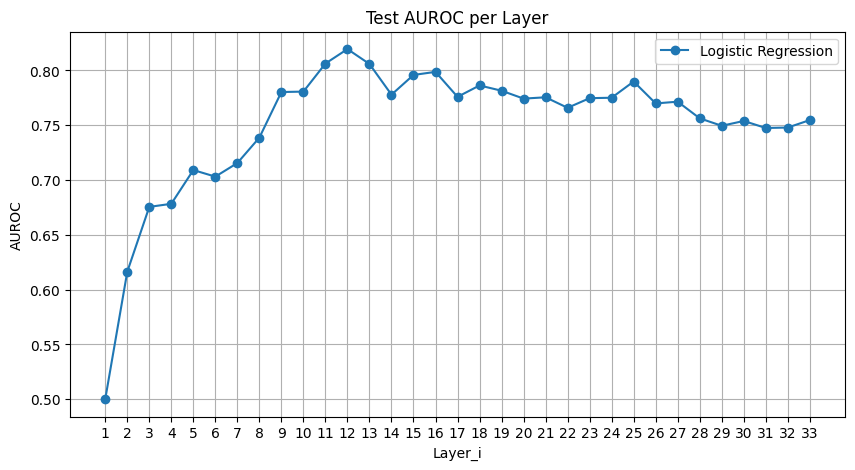

In [41]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

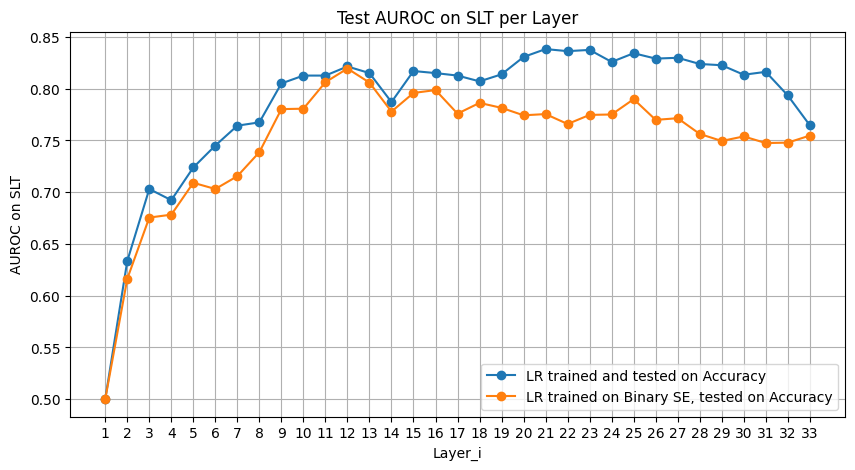

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8383 at 21 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8195 at 12 layer


In [42]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")